In [1]:
# !git clone https://github.com/sun-umn/Early_Stopping_for_DIP.git

In [2]:
import numpy as np
import skimage.metrics
import torch
import random
import torch.optim
import os
from third_party.models import *
from third_party.utils.denoising_utils import *
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid", {"axes.facecolor": ".9"})
os.environ['CUDA_VISIBLE_DEVICES'] ='0'

# seed = 2026

# torch.manual_seed(seed)
# torch.cuda.manual_seed(seed)
# torch.cuda.manual_seed_all(seed)

# np.random.seed(seed)
# random.seed(seed)

In [3]:
torch.backends.cudnn.enabled = True
torch.backends.cudnn.benchmark = False
dtype = torch.cuda.FloatTensor
buffer_size = 100
patience = 1000
width = 128
lr = 0.0001 #0.01 #1.5 #0.1 #
alg = 'adam'#'SGD'#
num_iter = 5000
l1 = False

In [4]:
class EarlyStop():
    def __init__(self, size, patience):
        self.patience = patience
        self.wait_count = 0
        self.best_score = float('inf')
        self.best_epoch = 0
        self.img_collection = []
        self.stop = False
        self.size = size

    def check_stop(self, current, cur_epoch):
      #stop when variance doesn't decrease for consecutive P(patience) times
        if current < self.best_score:
            self.best_score = current
            self.best_epoch = cur_epoch
            self.wait_count = 0
            should_stop = False
        else:
            self.wait_count += 1
            should_stop = self.wait_count >= self.patience
        return should_stop

    def update_img_collection(self, cur_img):
        self.img_collection.append(cur_img)
        if len(self.img_collection) > self.size:
            self.img_collection.pop(0)

    def get_img_collection(self):
        return self.img_collection

def myMetric(x1, x2):
    return ((x1 - x2) ** 2).sum() / x1.size
    # return (np.abs(x1 - x2)).sum() / x1.size

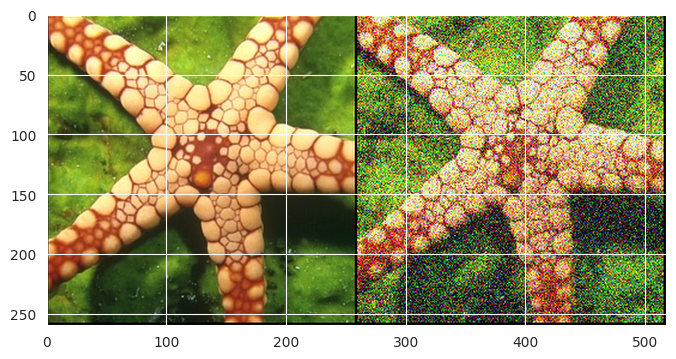

Noisy PSNR: 13.118678475358664
Noisy1 PSNR: 10.042682022269208
Noisy2 PSNR: 10.022958077632717


In [5]:
# #load image
# clean_img = './Dataset/Gaussian_Noise/Clean/House_clean.npz'
# corrupted_img = './Dataset/Gaussian_Noise/Gaussian_Noise_4/House_Gaussian_Noise_4.npz'
# raw_img_np = np.load(clean_img)['arr_0'] / 255.0
# raw_img_noisy_np = np.load(corrupted_img)['arr_0'] / 255.0

# fname = 'Dataset/butterfly.png'
fname = 'Dataset/starfish.png'
img_pil = crop_image(get_image(fname, -1)[0], d=32)
img_np = pil_to_np(img_pil)

img_noisy_pil, img_noisy_np = get_noisy_image(img_np, 0.26)
img_noisy_pil1, img_noisy_np1 = get_noisy_image(img_noisy_np, 0.26/0.8)
img_noisy_pil2, img_noisy_np2 = get_noisy_image(img_noisy_np, 0.26/0.8)

plot_image_grid([img_np, img_noisy_np], 4, 6) 
print(f'Noisy PSNR: {skimage.metrics.peak_signal_noise_ratio(img_np, img_noisy_np)}')
print(f'Noisy1 PSNR: {skimage.metrics.peak_signal_noise_ratio(img_np, img_noisy_np1)}')
print(f'Noisy2 PSNR: {skimage.metrics.peak_signal_noise_ratio(img_np, img_noisy_np2)}')

# img_noisy_torch = np_to_torch(img_noisy_np).type(dtype)
con = np.concatenate([img_noisy_np, img_noisy_np1], axis=0)
img_noisy_torch = np_to_torch(con).type(dtype)


In [6]:
# img_np = np.transpose(raw_img_np,(2,0,1))
# img_noisy_np = np.transpose(raw_img_noisy_np,(2,0,1))
# img_noisy_torch = np_to_torch(img_noisy_np).type(dtype)
# Network (exactly the same as the denoising DIP network, except with tunable width)

input_depth = 32 
n_channels = 6 #3
    
skip_n33d = width 
skip_n33u = width 
skip_n11 = 4
num_scales = 5

net = skip(input_depth, n_channels, num_channels_down = [skip_n33d]*num_scales,
                                    num_channels_up =   [skip_n33u]*num_scales,
                                    num_channels_skip = [skip_n11]*num_scales, 
                                    upsample_mode='bilinear', downsample_mode='stride',
                                    need_sigmoid=True, need_bias=True, pad='reflection', act_fun='LeakyReLU').type(dtype) 
    
net_input = get_noise(input_depth, 'noise', (img_np.shape[1], img_np.shape[2])).type(dtype).detach()
print(f'Net input PSNR: {skimage.metrics.peak_signal_noise_ratio(img_np, torch_to_np(net_input)[0:3])}')
# Loss

if l1:
    criterion = torch.nn.L1Loss().type(dtype)
else:
    criterion = torch.nn.MSELoss().type(dtype)

# Optimizer

p = get_params('net', net, net_input)  # network parameters to be optimized


def optimize(optimizer_type, parameters, closure, LR, num_iter):
    if optimizer_type == 'LBFGS':
        print('Starting optimization with LBFGS')
        def closure2():
            optimizer.zero_grad()
            return closure(num_iter)
        optimizer = torch.optim.LBFGS(parameters, max_iter=num_iter, lr=LR, tolerance_grad=-1, tolerance_change=-1)
        optimizer.step(closure2)

    else:
        opt_class = {
            'adam': torch.optim.Adam,
            'SGD': torch.optim.SGD,
            'RMSprop': torch.optim.RMSprop,
            'AdamW': torch.optim.AdamW,
            'RAdam': torch.optim.RAdam,
            # 'Adafactor': Adafactor #torch.optim.Adafactor
            'ASGD': torch.optim.ASGD
        }[optimizer_type]
        optimizer = opt_class(parameters, lr=LR)
        print(f'Starting optimization with {optimizer_type.upper()}')
        for j in range(num_iter):
            optimizer.zero_grad()
            loss = closure()
            optimizer.step()

# Optimize

reg_noise_std = 1./30. 
show_every = 1
loss_history = []
psnr_history = []
ssim_history = []
finalresult = []
variance_history = []
x_axis = []
earlystop = EarlyStop(size=buffer_size,patience=patience)
i = 0
def closure():
    global i
    #DIP
    net_input_perturbed = net_input + torch.zeros_like(net_input).normal_(std=reg_noise_std)
    r_img_torch = net(net_input_perturbed)
    total_loss = criterion(r_img_torch, img_noisy_torch)
    total_loss.backward()
    loss_history.append(total_loss.item())
    finalresult.append(r_img_torch.detach().cpu())
    if i % show_every == 0:
        # evaluate recovered image (PSNR, SSIM)
        r_img_np = torch_to_np(r_img_torch)
        r_img_np = r_img_np[0:3,:,:]
        psnr = skimage.metrics.peak_signal_noise_ratio(img_np, r_img_np)
        temp_img_np = np.transpose(img_np,(1,2,0))
        temp_r_img_np = np.transpose(r_img_np,(1,2,0))
        ssim = skimage.metrics.structural_similarity(temp_img_np, temp_r_img_np, channel_axis=-1, data_range=1.0)
        psnr_history.append(psnr)
        ssim_history.append(ssim)

        #variance hisotry
        r_img_np = r_img_np.reshape(-1)
        earlystop.update_img_collection(r_img_np)
        img_collection = earlystop.get_img_collection()
        if len(img_collection) == buffer_size:
            ave_img = np.mean(img_collection,axis = 0)
            variance = []
            for tmp in img_collection:
                variance.append(myMetric(ave_img, tmp))
            cur_var = np.mean(variance)
            cur_epoch = i
            variance_history.append(cur_var)
            x_axis.append(cur_epoch)
            if earlystop.stop == False:
                earlystop.stop = earlystop.check_stop(cur_var, cur_epoch)
    i = i + 1
    return total_loss

Net input PSNR: 6.41079536131067


In [7]:
# for iterator in range(num_iter):
    # optimizer.zero_grad()
    # closure(iterator)
    # optimizer.step()
optimize(alg, p, closure, lr, num_iter)

Starting optimization with ADAM


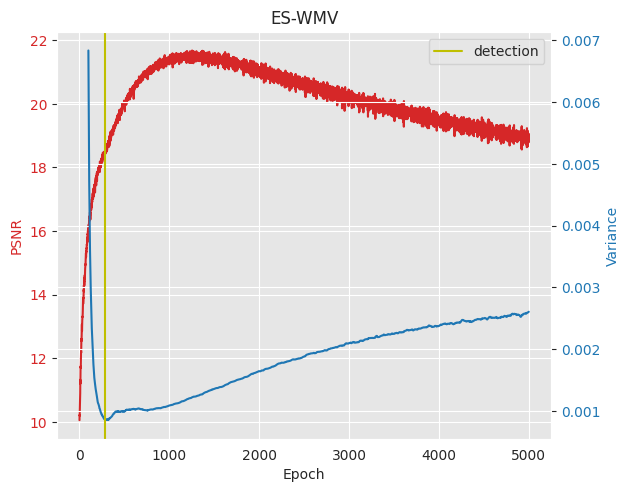

In [8]:
#show PSNR and variance history and detection
fig, ax1 = plt.subplots()

color = 'tab:red'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('PSNR', color=color)
ax1.plot(psnr_history, color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()

color = 'tab:blue'
ax2.set_ylabel('Variance', color=color)
ax2.plot(x_axis, variance_history, color=color)
ax2.tick_params(axis='y', labelcolor=color)
fig.tight_layout()
plt.title('ES-WMV')
plt.axvline(x=earlystop.best_epoch, label='detection',color='y')
plt.legend()
plt.show()

In [9]:
max_psnr = np.max(psnr_history)
max_psnr_idx = np.argmax(psnr_history)
print(f'True max PSNR: {max_psnr:.4f}, Iter: {max_psnr_idx}')

print(f'Early stop PSNR: {psnr_history[earlystop.best_epoch]}, iter: {earlystop.best_epoch}')
#leaves RB
# True max PSNR: 21.1994, Iter: 700
# Early stop PSNR: 20.845727653878154, iter: 679
# 0-2 mse 
# Min mse: 53.6053, Iter: 773, PSNR: 20.7393
# Max mse: 79.9475, Iter: 27, PSNR: 11.6672
# True max PSNR: 21.1994, Iter: 700
# 2-0 mse 
# Min mse: 52.7645, Iter: 698, PSNR: 20.8920
# Max mse: 81.5054, Iter: 20, PSNR: 11.6639
# True max PSNR: 21.1994, Iter: 700
# 0-2 bias
# Min bias: 0.2073, Iter: 27, PSNR: 11.6672
# Max bias: 0.3682, Iter: 773, PSNR: 20.7393
# True max PSNR: 21.1994, Iter: 700
# 2-0 bias
# Min bias: 0.1961, Iter: 20, PSNR: 11.6639
# Max bias: 0.3653, Iter: 578, PSNR: 20.9927
# True max PSNR: 21.1994, Iter: 700

# butterfly
# True max PSNR: 22.7197, Iter: 515
# Early stop PSNR: 22.566275405942704, iter: 487
# Closest pair: ('R', 'G')
# 0-1 mse
# Min mse: 66.7704, Iter: 655, PSNR: 21.7295
# Max mse: 88.7097, Iter: 21, PSNR: 12.7781
# True max PSNR: 22.7197, Iter: 515
# 1-0 mse
# Min mse: 67.5836, Iter: 595, PSNR: 22.2113
# Max mse: 86.7169, Iter: 4750, PSNR: 13.9104
# True max PSNR: 22.7197, Iter: 515

#True max PSNR: 22.7144, Iter: 505
# Early stop PSNR: 22.651516216033933, iter: 523
#True max PSNR: 22.6649, Iter: 565
# Early stop PSNR: 22.400307726418895, iter: 534
#True max PSNR: 22.6837, Iter: 546
# Early stop PSNR: 22.368632797214936, iter: 494

True max PSNR: 21.6735, Iter: 1253
Early stop PSNR: 18.53286422186655, iter: 286


# Ours

In [10]:
def residual_spectral_moment2_image(x, alpha=1.0, eps=1e-12):
    rr = x 
    C, H, W = rr.shape
    
    Rf = torch.fft.fft2(rr, norm='ortho')
    Rf = torch.fft.fftshift(Rf, dim=(-2, -1))

    fy = torch.fft.fftfreq(H, d=1.0, device=rr.device)
    fx = torch.fft.fftfreq(W, d=1.0, device=rr.device)
    
    fy = torch.fft.fftshift(fy)
    fx = torch.fft.fftshift(fx)
    
    grid_y, grid_x = torch.meshgrid(fy, fx, indexing='ij')
    freq_radius = torch.sqrt(grid_x**2 + grid_y**2)

    power = torch.abs(Rf)**2

    weighted_power = (freq_radius**alpha) * power
    numerator = torch.sum(weighted_power)

    denominator = torch.sum(rr**2)

    return numerator / (denominator + eps)
def residual_spectral_moment2(x, y, alpha=1.0, eps=1e-12):
    rr = x - y  
    B, H, W = rr.shape

    Rf = torch.fft.fft2(rr, norm='ortho')
    Rf = torch.fft.fftshift(Rf, dim=(-2, -1))

    fy = torch.fft.fftfreq(H, d=1.0, device=rr.device)
    fx = torch.fft.fftfreq(W, d=1.0, device=rr.device)

    fy = torch.fft.fftshift(fy)
    fx = torch.fft.fftshift(fx)
    
    grid_y, grid_x = torch.meshgrid(fy, fx, indexing='ij')
    freq_radius = torch.sqrt(grid_x**2 + grid_y**2)

    power = torch.abs(Rf)**2

    weighted_power = (freq_radius**alpha) * power
    numerator = torch.sum(weighted_power)

    denominator = torch.sum(rr**2)

    return numerator / (denominator + eps)

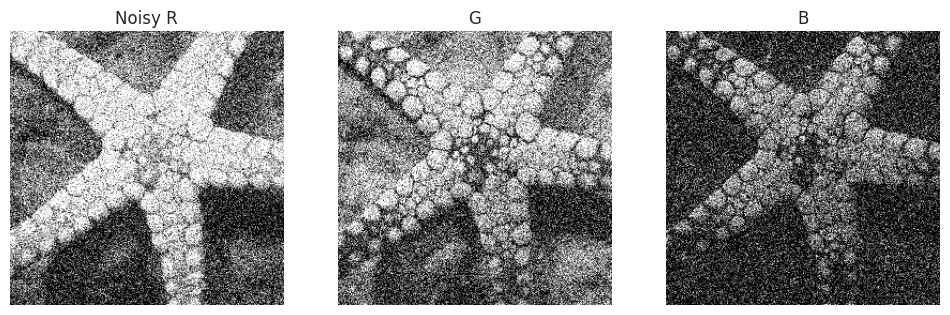

In [11]:
fig, axs = plt.subplots(1,3, figsize=(12,4))

axs[0].imshow(img_noisy_torch[0,0].cpu(), cmap='gray')
axs[0].set_title("Noisy R")

axs[1].imshow(img_noisy_torch[0,1].cpu(), cmap='gray')
axs[1].set_title("G")

axs[2].imshow(img_noisy_torch[0,2].cpu(), cmap='gray')
axs[2].set_title("B")

for ax in axs:
    ax.axis('off')
# plt.savefig(f'{savename}noisyrgb.png', dpi=300, bbox_inches='tight')

In [12]:
def closest_two_rgb_channels(img):
    assert img.shape[0] == 3

    channel_names = ['R', 'G', 'B']
    pairs = [(0, 1), (0, 2), (1, 2)]

    dists = {}
    for i, j in pairs:
        # L2 distance / RMSE
        dist = torch.sqrt(torch.mean((img[i] - img[j]) ** 2))
        dists[(channel_names[i], channel_names[j])] = dist.item()

    best_pair = min(dists, key=dists.get)

    return best_pair, dists
best_pair, dists = closest_two_rgb_channels(img_noisy_torch[0,0:3,:,:])#(np_to_torch(img_np).type(dtype)[0,:,:,:])#

print("Closest pair:", best_pair)
print(dists)

Closest pair: ('R', 'G')
{('R', 'G'): 0.34869682788848877, ('R', 'B'): 0.41955968737602234, ('G', 'B'): 0.3922642469406128}


In [13]:
records = []

psnr_vals = np.array(psnr_history)
max_psnr = np.max(psnr_vals)
max_psnr_idx = np.argmax(psnr_vals)
print(f'True max PSNR: {max_psnr:.4f}, Iter: {max_psnr_idx}')
for best_channel in range(3):  # 0,1,2
    for best_channelx in range(3):
        spec_vals=[]
        # fig, ax1 = plt.subplots(figsize=(30,20))
        # ax2 = ax1.twinx()
        for output in finalresult:
            spec_vals.append(torch.norm(img_noisy_torch[0,best_channel,:,:].cpu()-output[:,best_channelx,:,:]))
        vals = np.array(spec_vals)
        min_idx = np.argmin(vals[20:]) + 20
        min_bias = vals[min_idx]    
        co_min_psnr = psnr_history[min_idx]
        print(f'Min mse: {min_bias:.4f}, Iter: {min_idx}, PSNR: {co_min_psnr:.4f}')
        max_idx = np.argmax(vals[20:]) + 20
        max_bias = vals[max_idx]    
        co_max_psnr = psnr_history[max_idx]
        print(f'Max mse: {max_bias:.4f}, Iter: {max_idx}, PSNR: {co_max_psnr:.4f}')
        records.append({
            "y_channel": best_channel,
            "xhat_channel": best_channelx,

            "min_mse_iter": min_idx,
            "min_mse": min_bias,
            "psnr_at_min_mse": co_min_psnr,

            "max_mse_iter": max_idx,
            "max_mse": max_bias,
            "psnr_at_max_mse": co_max_psnr,

            "true_max_psnr_iter": max_psnr_idx,
            "true_max_psnr": max_psnr,

            "min_iter_gap_to_max_psnr": abs(min_idx - max_psnr_idx),
            "max_iter_gap_to_max_psnr": abs(max_idx - max_psnr_idx),

            "min_psnr_gap_to_max_psnr": abs(co_min_psnr - max_psnr),
            "max_psnr_gap_to_max_psnr": abs(co_max_psnr - max_psnr),
        })
        """
        # plt.plot(losses, spec_vals, marker='o', linestyle='-', label=opt_name)
        # 左轴：Spectral Bias
        ax1.set_xlabel("Loss", fontsize=50)
        ax1.set_ylabel("$y-\hat{x}$ mse residual", color='black', fontsize=50)
        ax1.plot(loss_history, spec_vals, marker='o', linestyle='-', label='Ours', color='green')
        ax1.tick_params(axis='both', labelsize=40)   
        ax2.tick_params(axis='y', labelsize=40) 

        # 右轴：PSNR
        ax2.set_ylabel("PSNR", color='black', fontsize=50)
        ax2.plot(loss_history, psnr_history, label=f'Ours', marker='.', linestyle=' ', color = 'purple')

        # PSNR peak
        ax2.axvline(x=loss_history[max_psnr_idx],
                color='red',
                linestyle='--',
                linewidth=3,
                label='Max PSNR')

        # Min bias
        ax2.axvline(x=loss_history[min_idx],
                color='blue',
                linestyle='--',
                linewidth=3,
                label='Min MSE')
        ax2.axvline(x=loss_history[max_idx],
                color='orange',
                linestyle='--',
                linewidth=3,
                label='Max MSE')
        # Legend
        h1, l1 = ax1.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        ax1.legend(h1 + h2, l1 + l2, fontsize=50,loc='lower right')
        plt.xticks(fontsize=40)
        plt.yticks(fontsize=40)
        # plt.grid(True, which='both', axis='both',color='black', linestyle='-', linewidth=1, alpha=1)
        ax1.grid(True, axis='both', color='black', linestyle='-', linewidth=1, alpha=1)
        plt.title(
            f'rgb channel $y_{best_channel}-\\hat{{x}}_{best_channelx}$\n'
            # f'Local (after 300 iter.) Min bias: {min_bias:.4f}, Iter: {min_idx}, PSNR: {co_psnr:.4f}\n'
            # f'Local (after Iter. 20) Min mse: {min_bias:.4f}, Iter: {min_idx}, PSNR: {co_psnr:.4f}\n'
            f'Local (after Iter. 20) Min MSE: {min_bias:.4f}, Iter: {min_idx}, PSNR: {co_min_psnr:.4f}\n'
            f'Local (after Iter. 20) Max MSE: {max_bias:.4f}, Iter: {max_idx}, PSNR: {co_max_psnr:.4f}\n'
            f'True max PSNR: {max_psnr:.4f}, Iter: {max_psnr_idx}',
            fontsize=40
        )
        # plt.savefig(f'{savename}rgb_result_mse_y_{best_channel}-x_{best_channelx}.png', dpi=300, bbox_inches='tight')
        plt.show()
        """
print(100 * '-')
best_min = min(records, key=lambda r: r["min_psnr_gap_to_max_psnr"])
best_max = min(records, key=lambda r: r["max_psnr_gap_to_max_psnr"])

gap_min = best_min["min_psnr_gap_to_max_psnr"]
gap_max = best_max["max_psnr_gap_to_max_psnr"]

if gap_min <= gap_max:
    best_row = best_min
    best_type = "min_mse"
    best_gap = gap_min
    best_iter = best_row["min_mse_iter"]
    best_psnr = best_row["psnr_at_min_mse"]
else:
    best_row = best_max
    best_type = "max_mse"
    best_gap = gap_max
    best_iter = best_row["max_mse_iter"]
    best_psnr = best_row["psnr_at_max_mse"]

print("Best type:", best_type)
print("y_channel:", best_row["y_channel"])
print("xhat_channel:", best_row["xhat_channel"])
print("iter:", best_iter)
print("PSNR at selected point:", best_psnr)
print("true max PSNR:", best_row["true_max_psnr"])
print("true max PSNR iter:", best_row["true_max_psnr_iter"])
print("gap:", best_gap)

True max PSNR: 21.6735, Iter: 1253
Min mse: 48.5705, Iter: 4960, PSNR: 18.7939
Max mse: 69.7745, Iter: 23, PSNR: 12.5381
Min mse: 67.4080, Iter: 2053, PSNR: 21.2150
Max mse: 76.8427, Iter: 4799, PSNR: 18.8010
Min mse: 72.0651, Iter: 43, PSNR: 13.9058
Max mse: 97.8150, Iter: 4545, PSNR: 18.7576
Min mse: 70.8680, Iter: 3289, PSNR: 19.5426
Max mse: 78.1516, Iter: 45, PSNR: 13.8909
Min mse: 51.1406, Iter: 4980, PSNR: 18.6484
Max mse: 71.9373, Iter: 23, PSNR: 12.5381
Min mse: 71.5747, Iter: 26, PSNR: 12.9232
Max mse: 88.2311, Iter: 4980, PSNR: 18.6484
Min mse: 92.5408, Iter: 64, PSNR: 14.8445
Max mse: 96.9418, Iter: 4830, PSNR: 19.2632
Min mse: 82.4972, Iter: 766, PSNR: 21.0543
Max mse: 87.2797, Iter: 4801, PSNR: 18.8605
Min mse: 48.7313, Iter: 4973, PSNR: 19.0653
Max mse: 85.2662, Iter: 20, PSNR: 12.6004
----------------------------------------------------------------------------------------------------
Best type: min_mse
y_channel: 0
xhat_channel: 1
iter: 2053
PSNR at selected point: 21.2

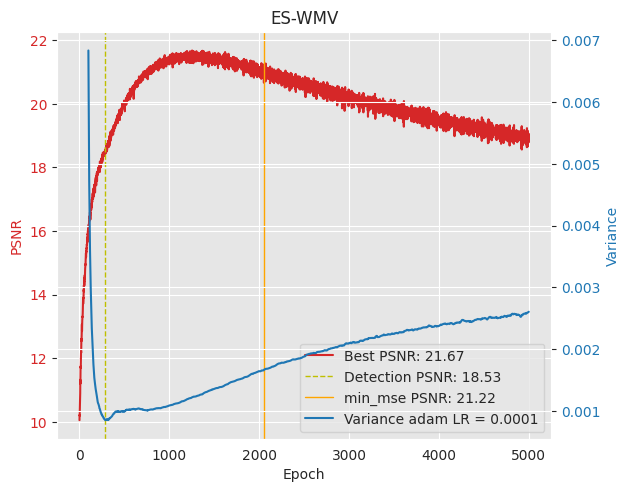

In [14]:
# show PSNR and variance history and detection
fig, ax1 = plt.subplots()

color = 'tab:red'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('PSNR', color=color)
ax1.plot(psnr_history, color=color, label=f'Best PSNR: {max_psnr:.2f}')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()

color = 'tab:blue'
ax2.set_ylabel('Variance', color=color)
ax2.plot(x_axis, variance_history, color=color, label=f'Variance {alg} LR = {lr}')
ax2.tick_params(axis='y', labelcolor=color)

# mse = [v.item() for v in best_row["mse"]]
# ax2.set_ylabel('MSE', color='green')
# ax2.plot(mse, color='green', label=f'mse')
# ax2.tick_params(axis='y', labelcolor='green')

# Early stopping detection line
ax1.axvline(
    x=earlystop.best_epoch,
    label=f'Detection PSNR: {psnr_history[earlystop.best_epoch]:.2f}',
    color='y',
    linestyle='--',
    linewidth=1
)

# Minimum PSNR gap line
ax1.axvline(
    x=best_iter,
    label=f'{best_type} PSNR: {best_psnr:.2f}',
    color='orange',
    linestyle='-',
    linewidth=1
)

fig.tight_layout()
plt.title('ES-WMV')

# 合并两个 y-axis 的 legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='best')

plt.show()

Max bias: 0.3801, Iter: 1362, PSNR: 21.4771


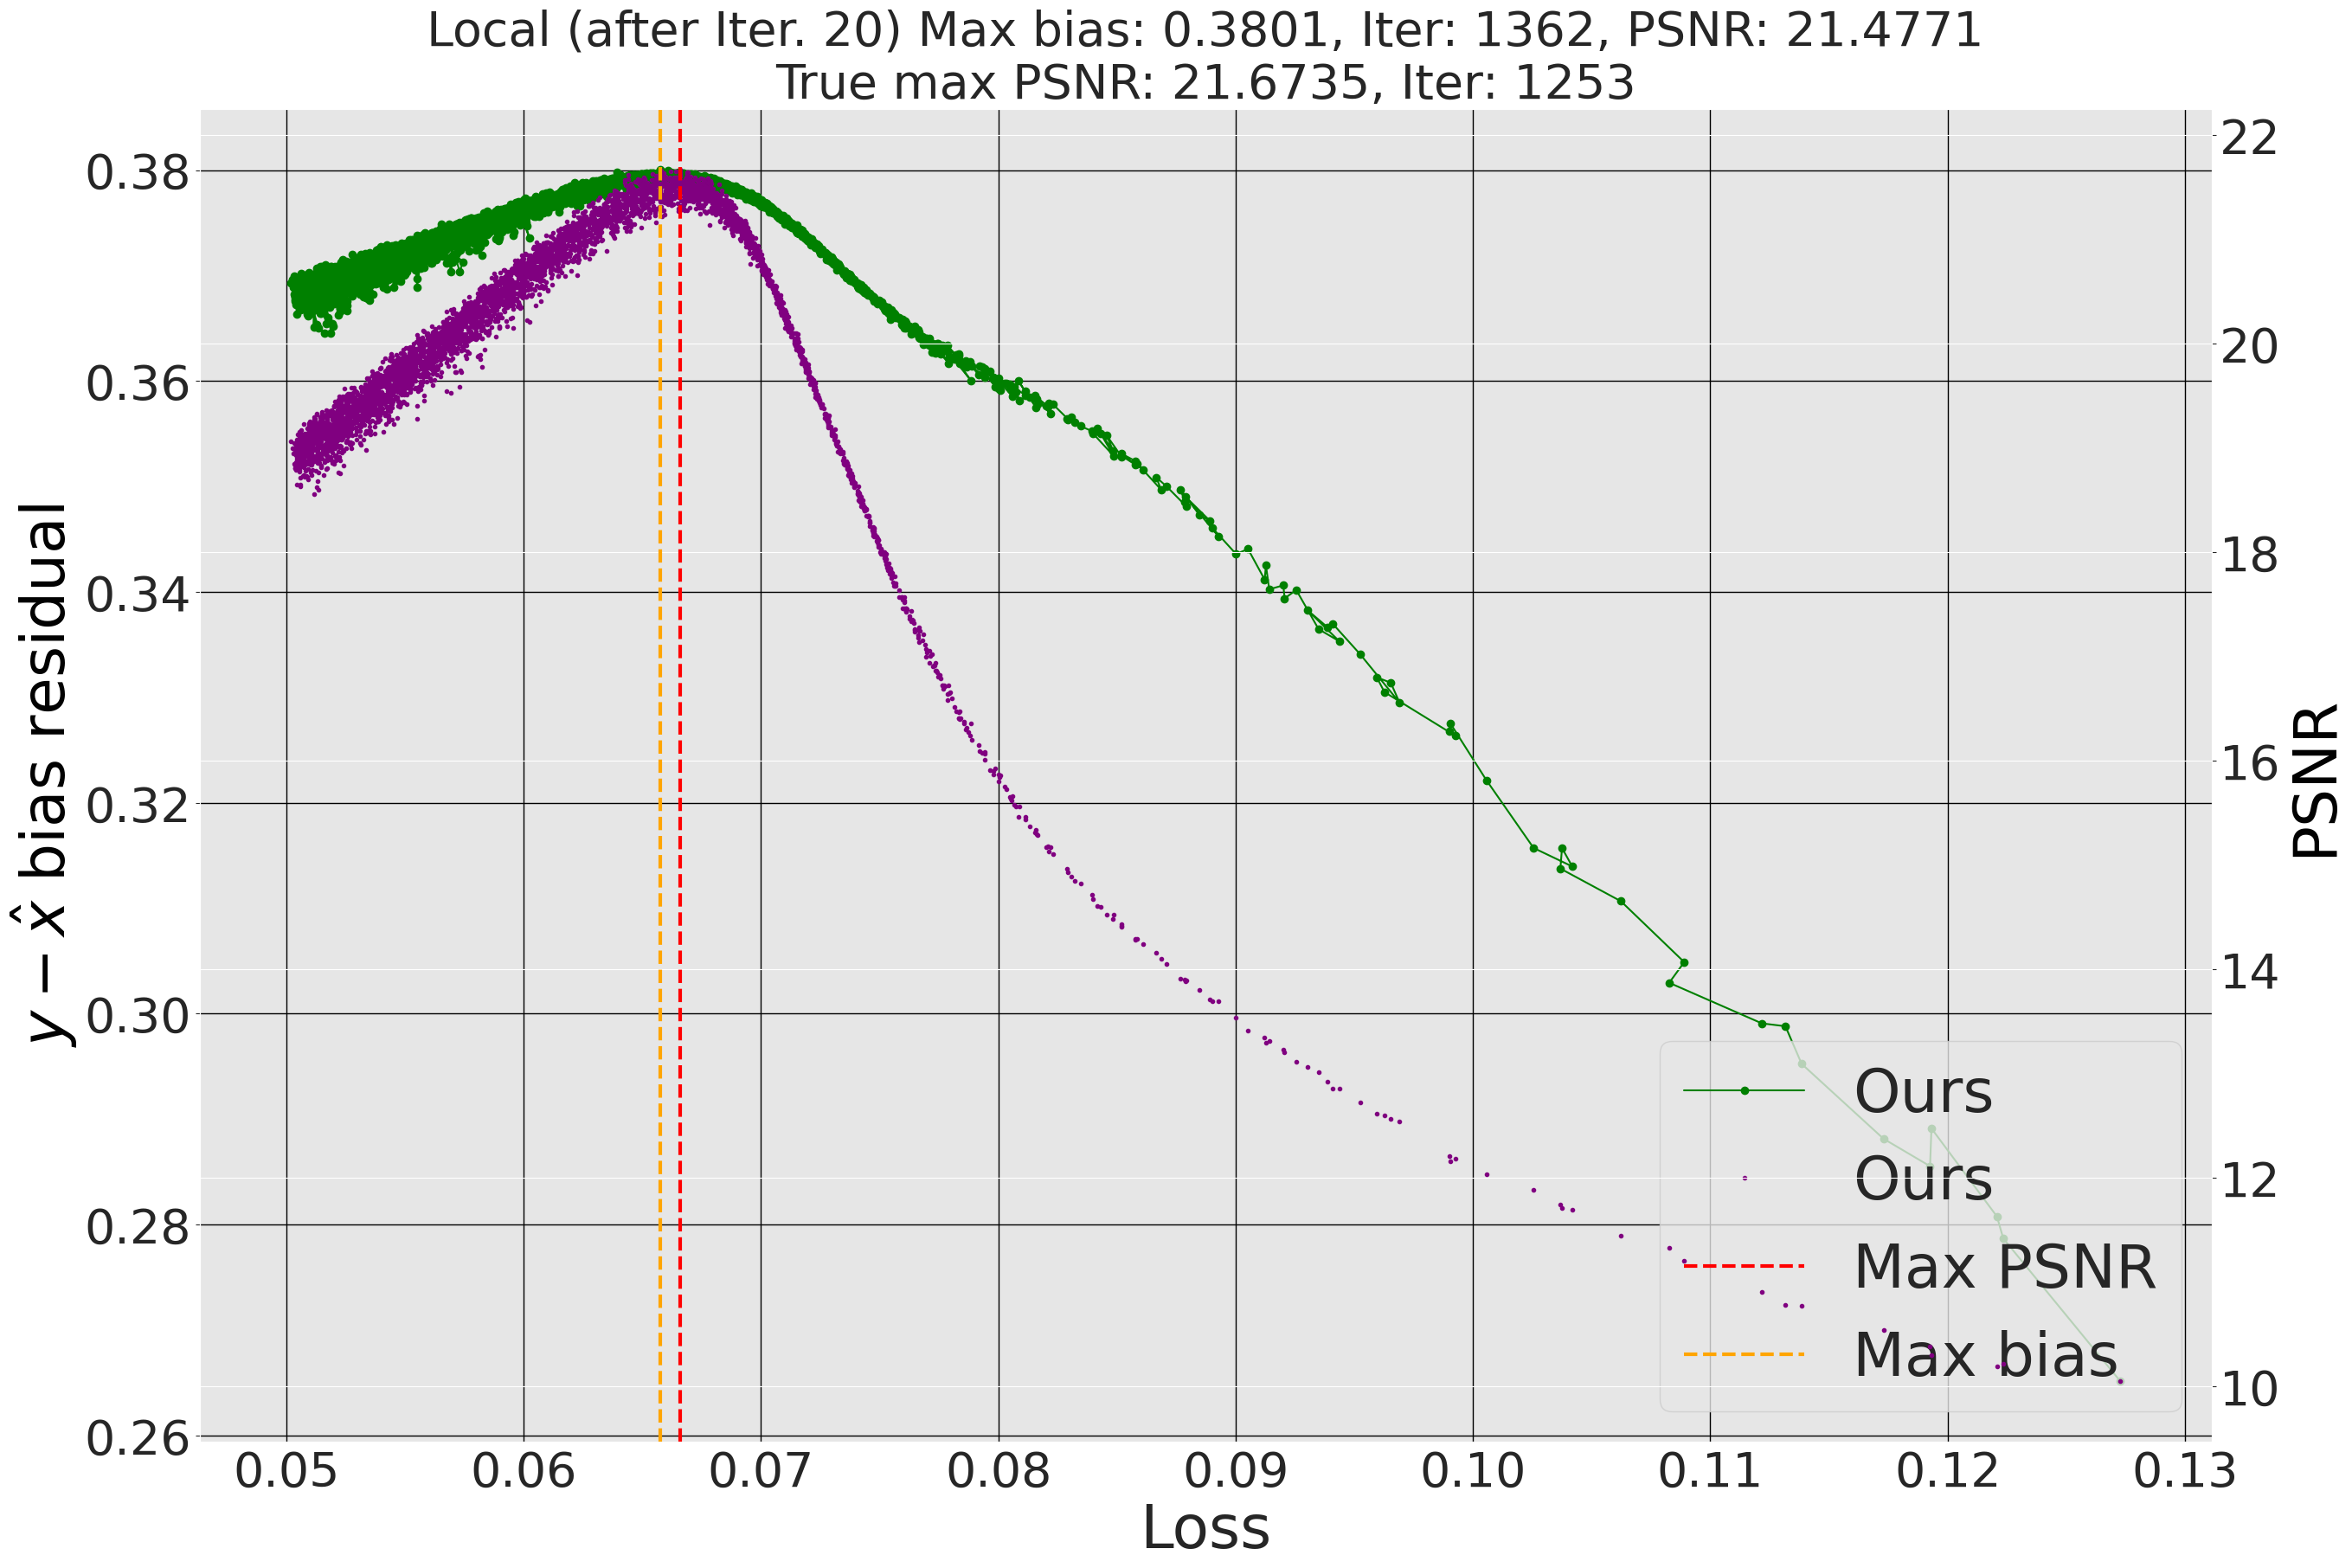

In [31]:
spec_valsy2 = []
for output in finalresult:
    spec_valsy2.append(residual_spectral_moment2(np_to_torch(img_noisy_np2)[0,:,:,:],output[0,3:6,:,:]))
vals = np.array(spec_valsy2)
max_idxy2 = np.argmax(vals[20:]) + 20
# min_idx = np.argmin(vals[20:]) + 20
max_bias = vals[max_idxy2]    
co_max_psnr = psnr_history[max_idxy2]
print(f'Max bias: {max_bias:.4f}, Iter: {max_idxy2}, PSNR: {co_max_psnr:.4f}')
fig, ax1 = plt.subplots(figsize=(30,20))
ax2 = ax1.twinx()
ax1.set_xlabel("Loss", fontsize=50)
ax1.set_ylabel("$y-\hat{x}$ bias residual", color='black', fontsize=50)
ax1.plot(loss_history, spec_valsy2, marker='o', linestyle='-', label='Ours', color='green')
ax1.tick_params(axis='both', labelsize=40)   
ax2.tick_params(axis='y', labelsize=40) 
ax2.set_ylabel("PSNR", color='black', fontsize=50)
ax2.plot(loss_history, psnr_history, label=f'Ours', marker='.', linestyle=' ', color = 'purple')

# PSNR peak
ax2.axvline(x=loss_history[max_psnr_idx],color='red',linestyle='--',linewidth=3,label='Max PSNR')

# Min bias
# ax2.axvline(x=loss_history[min_idx],
#         color='blue',
#         linestyle='--',
#         linewidth=3,
#         label='Min bias')
ax2.axvline(x=loss_history[max_idxy2],
        color='orange',
        linestyle='--',
        linewidth=3,
        label='Max bias')
        # Legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, fontsize=50,loc='lower right')
plt.xticks(fontsize=40)
plt.yticks(fontsize=40)
ax1.grid(True, axis='both', color='black', linestyle='-', linewidth=1, alpha=1)
plt.title(
    # f'rgb channel $y_{best_channel}-\\hat{{x}}_{best_channelx}$\n'
    # f'Local (after 300 iter.) Min bias: {min_bias:.4f}, Iter: {min_idx}, PSNR: {co_psnr:.4f}\n'
    # f'Local (after Iter. 20) Min mse: {min_bias:.4f}, Iter: {min_idx}, PSNR: {co_psnr:.4f}\n'
    # f'Local (after Iter. 20) Min bias: {min_bias:.4f}, Iter: {min_idx}, PSNR: {co_min_psnr:.4f}\n'
    f'Local (after Iter. 20) Max bias: {max_bias:.4f}, Iter: {max_idxy2}, PSNR: {co_max_psnr:.4f}\n'
    f'True max PSNR: {max_psnr:.4f}, Iter: {max_psnr_idx}',
    fontsize=40
)
# plt.savefig(f'{savename}rgb_result_mse_y_{best_channel}-x_{best_channelx}.png', dpi=300, bbox_inches='tight')
plt.show()

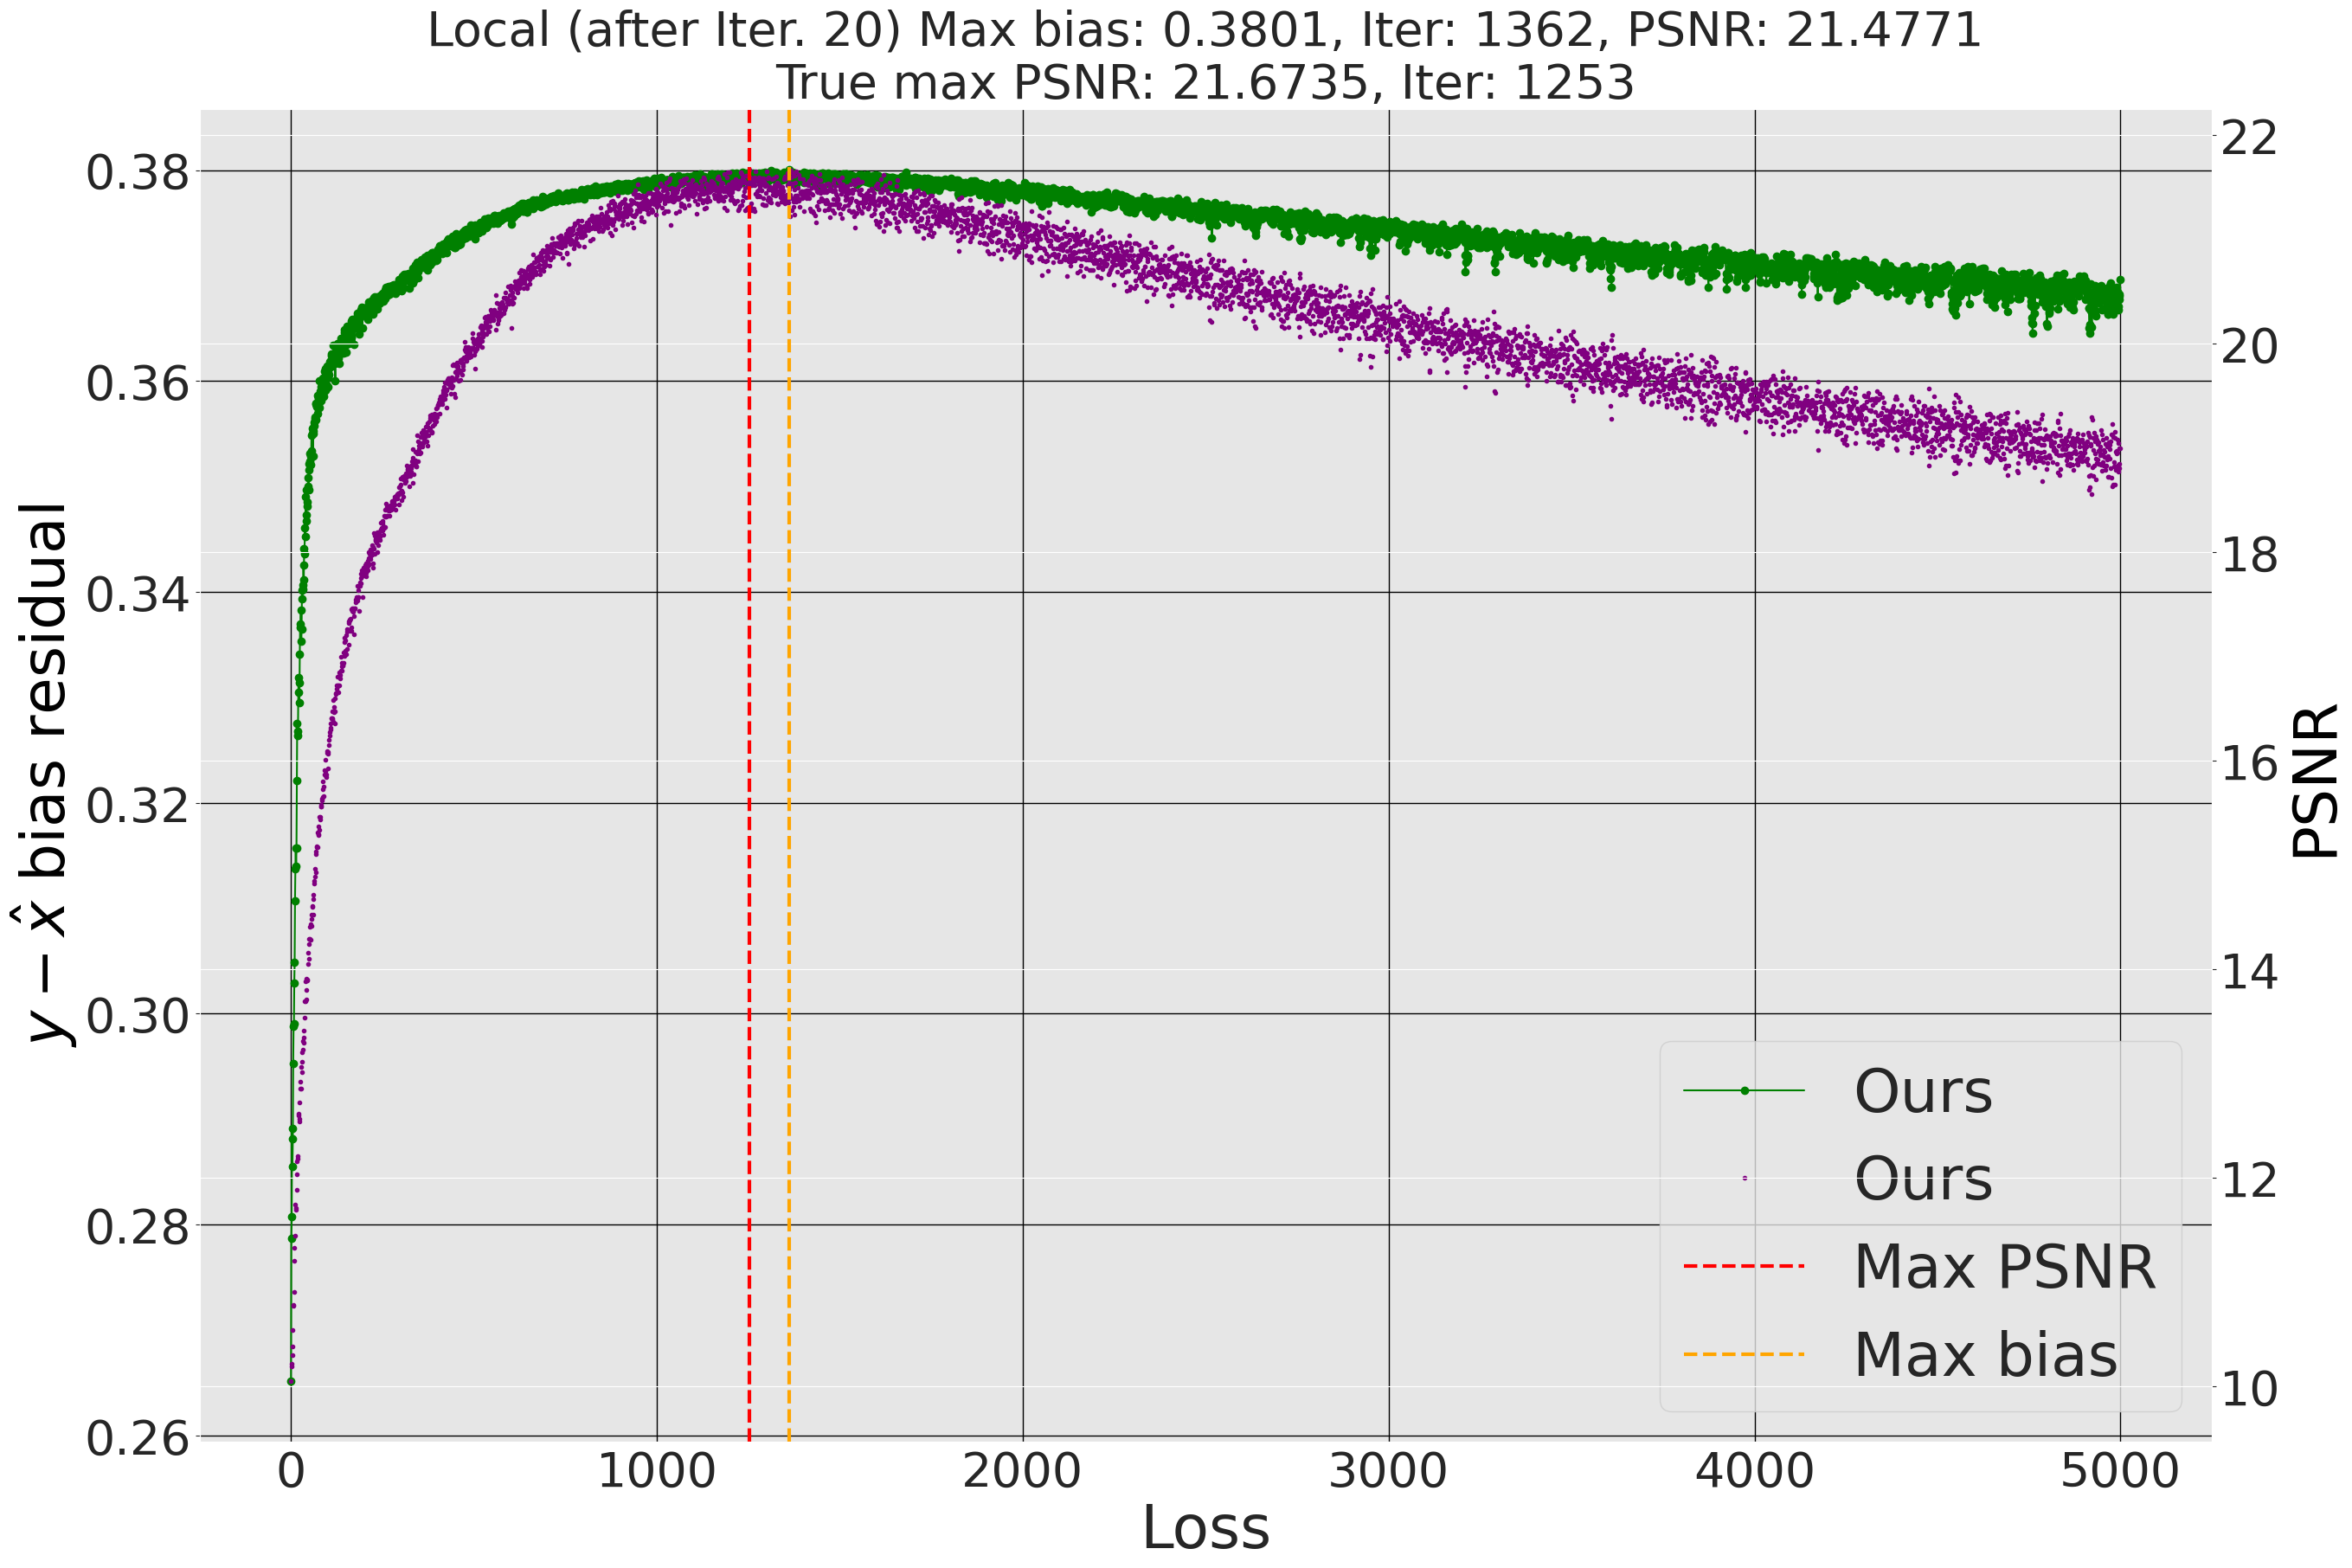

In [32]:
fig, ax1 = plt.subplots(figsize=(30,20))
ax2 = ax1.twinx()
ax1.set_xlabel("Loss", fontsize=50)
ax1.set_ylabel("$y-\hat{x}$ bias residual", color='black', fontsize=50)
ax1.plot(spec_valsy2, marker='o', linestyle='-', label='Ours', color='green')
ax1.tick_params(axis='both', labelsize=40)   
ax2.tick_params(axis='y', labelsize=40) 
ax2.set_ylabel("PSNR", color='black', fontsize=50)
ax2.plot(psnr_history, label=f'Ours', marker='.', linestyle=' ', color = 'purple')

# PSNR peak
ax2.axvline(x=max_psnr_idx,color='red',linestyle='--',linewidth=3,label='Max PSNR')

# Min bias
# ax2.axvline(x=loss_history[min_idx],
#         color='blue',
#         linestyle='--',
#         linewidth=3,
#         label='Min bias')
ax2.axvline(x=max_idxy2,
        color='orange',
        linestyle='--',
        linewidth=3,
        label='Max bias')
        # Legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, fontsize=50,loc='lower right')
plt.xticks(fontsize=40)
plt.yticks(fontsize=40)
ax1.grid(True, axis='both', color='black', linestyle='-', linewidth=1, alpha=1)
plt.title(
    # f'rgb channel $y_{best_channel}-\\hat{{x}}_{best_channelx}$\n'
    # f'Local (after 300 iter.) Min bias: {min_bias:.4f}, Iter: {min_idx}, PSNR: {co_psnr:.4f}\n'
    # f'Local (after Iter. 20) Min mse: {min_bias:.4f}, Iter: {min_idx}, PSNR: {co_psnr:.4f}\n'
    # f'Local (after Iter. 20) Min bias: {min_bias:.4f}, Iter: {min_idx}, PSNR: {co_min_psnr:.4f}\n'
    f'Local (after Iter. 20) Max bias: {max_bias:.4f}, Iter: {max_idxy2}, PSNR: {co_max_psnr:.4f}\n'
    f'True max PSNR: {max_psnr:.4f}, Iter: {max_psnr_idx}',
    fontsize=40
)
# plt.savefig(f'{savename}rgb_result_mse_y_{best_channel}-x_{best_channelx}.png', dpi=300, bbox_inches='tight')
plt.show()

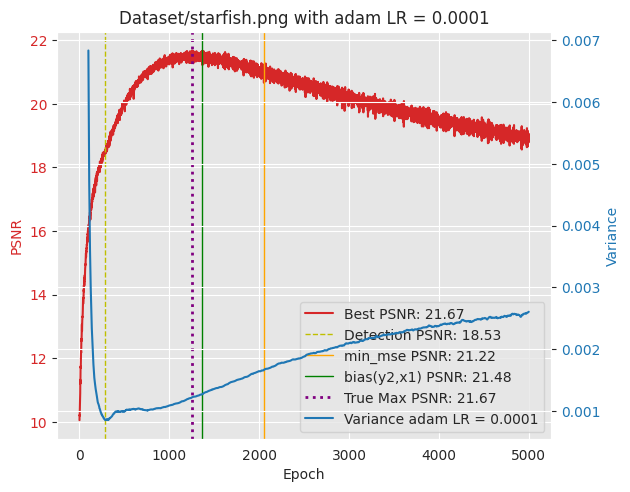

In [33]:
# show PSNR and variance history and detection
fig, ax1 = plt.subplots()

color = 'tab:red'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('PSNR', color=color)
ax1.plot(psnr_history, color=color, label=f'Best PSNR: {max_psnr:.2f}')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()

color = 'tab:blue'
ax2.set_ylabel('Variance', color=color)
ax2.plot(x_axis, variance_history, color=color, label=f'Variance {alg} LR = {lr}')
ax2.tick_params(axis='y', labelcolor=color)

# mse = [v.item() for v in best_row["mse"]]
# ax2.set_ylabel('MSE', color='green')
# ax2.plot(mse, color='green', label=f'mse')
# ax2.tick_params(axis='y', labelcolor='green')

# Early stopping detection line
ax1.axvline(
    x=earlystop.best_epoch,
    label=f'Detection PSNR: {psnr_history[earlystop.best_epoch]:.2f}',
    color='y',
    linestyle='--',
    linewidth=1
)

# Minimum PSNR gap line
ax1.axvline(
    x=best_iter,
    label=f'{best_type} PSNR: {best_psnr:.2f}',
    color='orange',
    linestyle='-',
    linewidth=1
)
ax1.axvline(
    x=max_idxy2,
    label=f'bias(y2,x1) PSNR: {co_max_psnr:.2f}',
    color='green',
    linestyle='-',
    linewidth=1
)

# True PSNR line
ax1.axvline(
    x=max_psnr_idx,
    label=f'True Max PSNR: {max_psnr:.2f}',
    color='purple',
    linestyle='dotted',
    linewidth=2
)
fig.tight_layout()
plt.title(f'{fname} with {alg} LR = {lr}')

# 合并两个 y-axis 的 legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='best')

plt.show()

In [23]:
def find_alpha_beta_from_two_noisy_fast(y1, y2, lr=1e-2, num_iter=1000, n_restarts=10, device=None):
    """
    y1, y2: shape [3, H, W] or [1, 3, H, W]

    Solve:
        min_{alpha,beta} ||Y1 alpha - Y2 beta||^2
        s.t. ||alpha||=1, ||beta||=1, alpha^T beta=0

    This version uses 3x3 Gram matrices, so it is much faster.
    """

    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    if isinstance(y1, np.ndarray):
        y1 = torch.from_numpy(y1).float()
    else:
        y1 = y1.detach().float().cpu()

    if isinstance(y2, np.ndarray):
        y2 = torch.from_numpy(y2).float()
    else:
        y2 = y2.detach().float().cpu()

    if y1.ndim == 4:
        y1 = y1[0]
    if y2.ndim == 4:
        y2 = y2[0]

    assert y1.shape[0] == 3
    assert y2.shape[0] == 3

    # [3, H, W] -> [N, 3]
    Y1 = y1.reshape(3, -1).T.to(device)
    Y2 = y2.reshape(3, -1).T.to(device)

    N = Y1.shape[0]

    # Gram matrices, shape [3, 3]
    A = (Y1.T @ Y1) / N
    B = (Y1.T @ Y2) / N
    C = (Y2.T @ Y2) / N

    best_loss = float("inf")
    best_alpha = None
    best_beta = None

    eps = 1e-12

    for restart in range(n_restarts):
        u = torch.randn(3, device=device, requires_grad=True)
        v = torch.randn(3, device=device, requires_grad=True)

        optimizer = torch.optim.Adam([u, v], lr=lr)

        for it in range(num_iter):
            optimizer.zero_grad()

            alpha = u / (torch.norm(u) + eps)

            # beta is projected to the orthogonal complement of alpha
            v_orth = v - torch.dot(v, alpha) * alpha
            beta = v_orth / (torch.norm(v_orth) + eps)

            loss = (
                alpha @ A @ alpha
                - 2.0 * alpha @ B @ beta
                + beta @ C @ beta
            )

            loss.backward()
            optimizer.step()

        with torch.no_grad():
            alpha = u / (torch.norm(u) + eps)
            v_orth = v - torch.dot(v, alpha) * alpha
            beta = v_orth / (torch.norm(v_orth) + eps)

            loss = (
                alpha @ A @ alpha
                - 2.0 * alpha @ B @ beta
                + beta @ C @ beta
            ).item()

            if loss < best_loss:
                best_loss = loss
                best_alpha = alpha.detach().cpu().numpy()
                best_beta = beta.detach().cpu().numpy()

    return best_alpha, best_beta, best_loss

In [24]:
alpha, beta, loss = find_alpha_beta_from_two_noisy_fast(
    y1=img_noisy_np1,
    y2=img_noisy_np2,
    lr=1e-2,
    num_iter=1000,
    n_restarts=10
)

print("alpha:", alpha)
print("beta:", beta)
print("alpha dot beta:", np.dot(alpha, beta))
print("loss:", loss)

alpha: [0.2643365 0.1988951 0.9436986]
beta: [ 0.8330706   0.44592267 -0.32733226]
alpha dot beta: -1.937151e-07
loss: 0.17730548977851868


In [25]:
def compute_fixed_alpha_beta_residual_first3(finalresult, y_ref, alpha, beta):
    """
    finalresult: list, each output shape [1, 6, H, W]
    y_ref: shape [6, H, W] or [3, H, W]
    alpha, beta: shape [3]

    Compute:
        R(t) = || alpha^T x_t[0:3] - beta^T y_ref[0:3] ||^2
    """

    residuals = []

    # only use first 3 channels of y_ref
    y_ref_3 = y_ref[0:3, :, :]

    gy = (
        beta[0] * y_ref_3[0]
        + beta[1] * y_ref_3[1]
        + beta[2] * y_ref_3[2]
    )

    for output in finalresult:
        # output: [1, 6, H, W]
        x_t = torch_to_np(output)[0:3, :, :]  # only first 3 channels

        fx = (
            alpha[0] * x_t[0]
            + alpha[1] * x_t[1]
            + alpha[2] * x_t[2]
        )

        residual = np.mean((fx - gy) ** 2)
        residuals.append(residual)

    return np.array(residuals)

In [26]:
fixed_residual = compute_fixed_alpha_beta_residual_first3(
    finalresult=finalresult,
    y_ref=img_noisy_np,
    alpha=alpha,
    beta=beta
)

In [40]:
start = 20

min_R_iter = np.argmin(fixed_residual[start:]) + start
max_R_iter = np.argmax(fixed_residual[start:]) + start

true_max_psnr_iter = np.argmax(psnr_history)
true_max_psnr = np.max(psnr_history)

print("Fixed alpha-beta residual min:")
print("iter:", min_R_iter)
print("R:", fixed_residual[min_R_iter])
print("PSNR:", psnr_history[min_R_iter])
print("iter gap:", abs(min_R_iter - true_max_psnr_iter))
print("PSNR gap:", true_max_psnr - psnr_history[min_R_iter])

print("\nFixed alpha-beta residual max:")
print("iter:", max_R_iter)
print("R:", fixed_residual[max_R_iter])
print("PSNR:", psnr_history[max_R_iter])
print("iter gap:", abs(max_R_iter - true_max_psnr_iter))
print("PSNR gap:", true_max_psnr - psnr_history[max_R_iter])

print("\nTrue max PSNR:")
print("iter:", true_max_psnr_iter)
print("PSNR:", true_max_psnr)

Fixed alpha-beta residual min:
iter: 1025
R: 0.0606768
PSNR: 21.47236629999209
iter gap: 228
PSNR gap: 0.20113528481661547

Fixed alpha-beta residual max:
iter: 22
R: 0.09674311
PSNR: 12.565226992971674
iter gap: 1231
PSNR gap: 9.10827459183703

True max PSNR:
iter: 1253
PSNR: 21.673501584808704


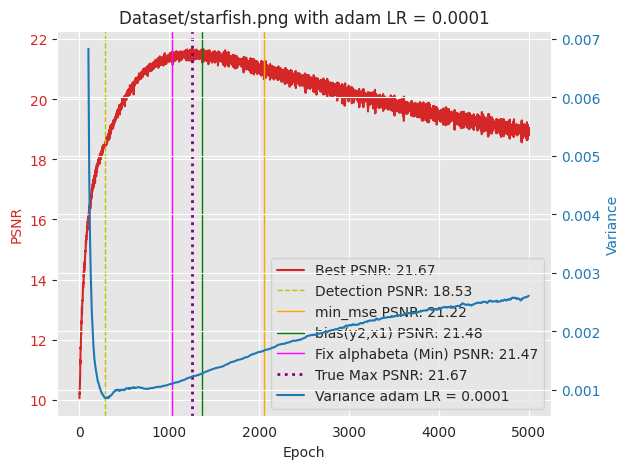

In [34]:
# show PSNR and variance history and detection
fig, ax1 = plt.subplots()

color = 'tab:red'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('PSNR', color=color)
ax1.plot(psnr_history, color=color, label=f'Best PSNR: {max_psnr:.2f}')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()

color = 'tab:blue'
ax2.set_ylabel('Variance', color=color)
ax2.plot(x_axis, variance_history, color=color, label=f'Variance {alg} LR = {lr}')
ax2.tick_params(axis='y', labelcolor=color)

# mse = [v.item() for v in best_row["mse"]]
# ax2.set_ylabel('MSE', color='green')
# ax2.plot(mse, color='green', label=f'mse')
# ax2.tick_params(axis='y', labelcolor='green')

# Early stopping detection line
ax1.axvline(
    x=earlystop.best_epoch,
    label=f'Detection PSNR: {psnr_history[earlystop.best_epoch]:.2f}',
    color='y',
    linestyle='--',
    linewidth=1
)

# Minimum PSNR gap line
ax1.axvline(
    x=best_iter,
    label=f'{best_type} PSNR: {best_psnr:.2f}',
    color='orange',
    linestyle='-',
    linewidth=1
)
ax1.axvline(
    x=max_idxy2,
    label=f'bias(y2,x1) PSNR: {co_max_psnr:.2f}',
    color='green',
    linestyle='-',
    linewidth=1
)
ax1.axvline(
    x=min_R_iter,
    label=f'Fix alphabeta (Min) PSNR: {psnr_history[min_R_iter]:.2f}',
    color='magenta',
    linestyle='-',
    linewidth=1
)
# True PSNR line
ax1.axvline(
    x=max_psnr_idx,
    label=f'True Max PSNR: {max_psnr:.2f}',
    color='purple',
    linestyle='dotted',
    linewidth=2
)
fig.tight_layout()
plt.title(f'{fname} with {alg} LR = {lr}')

fig.tight_layout()
plt.title(f'{fname} with {alg} LR = {lr}')

# 合并两个 y-axis 的 legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='best')

plt.show()

Min MSE: 132.8011, Iter: 1682, PSNR: 21.4001


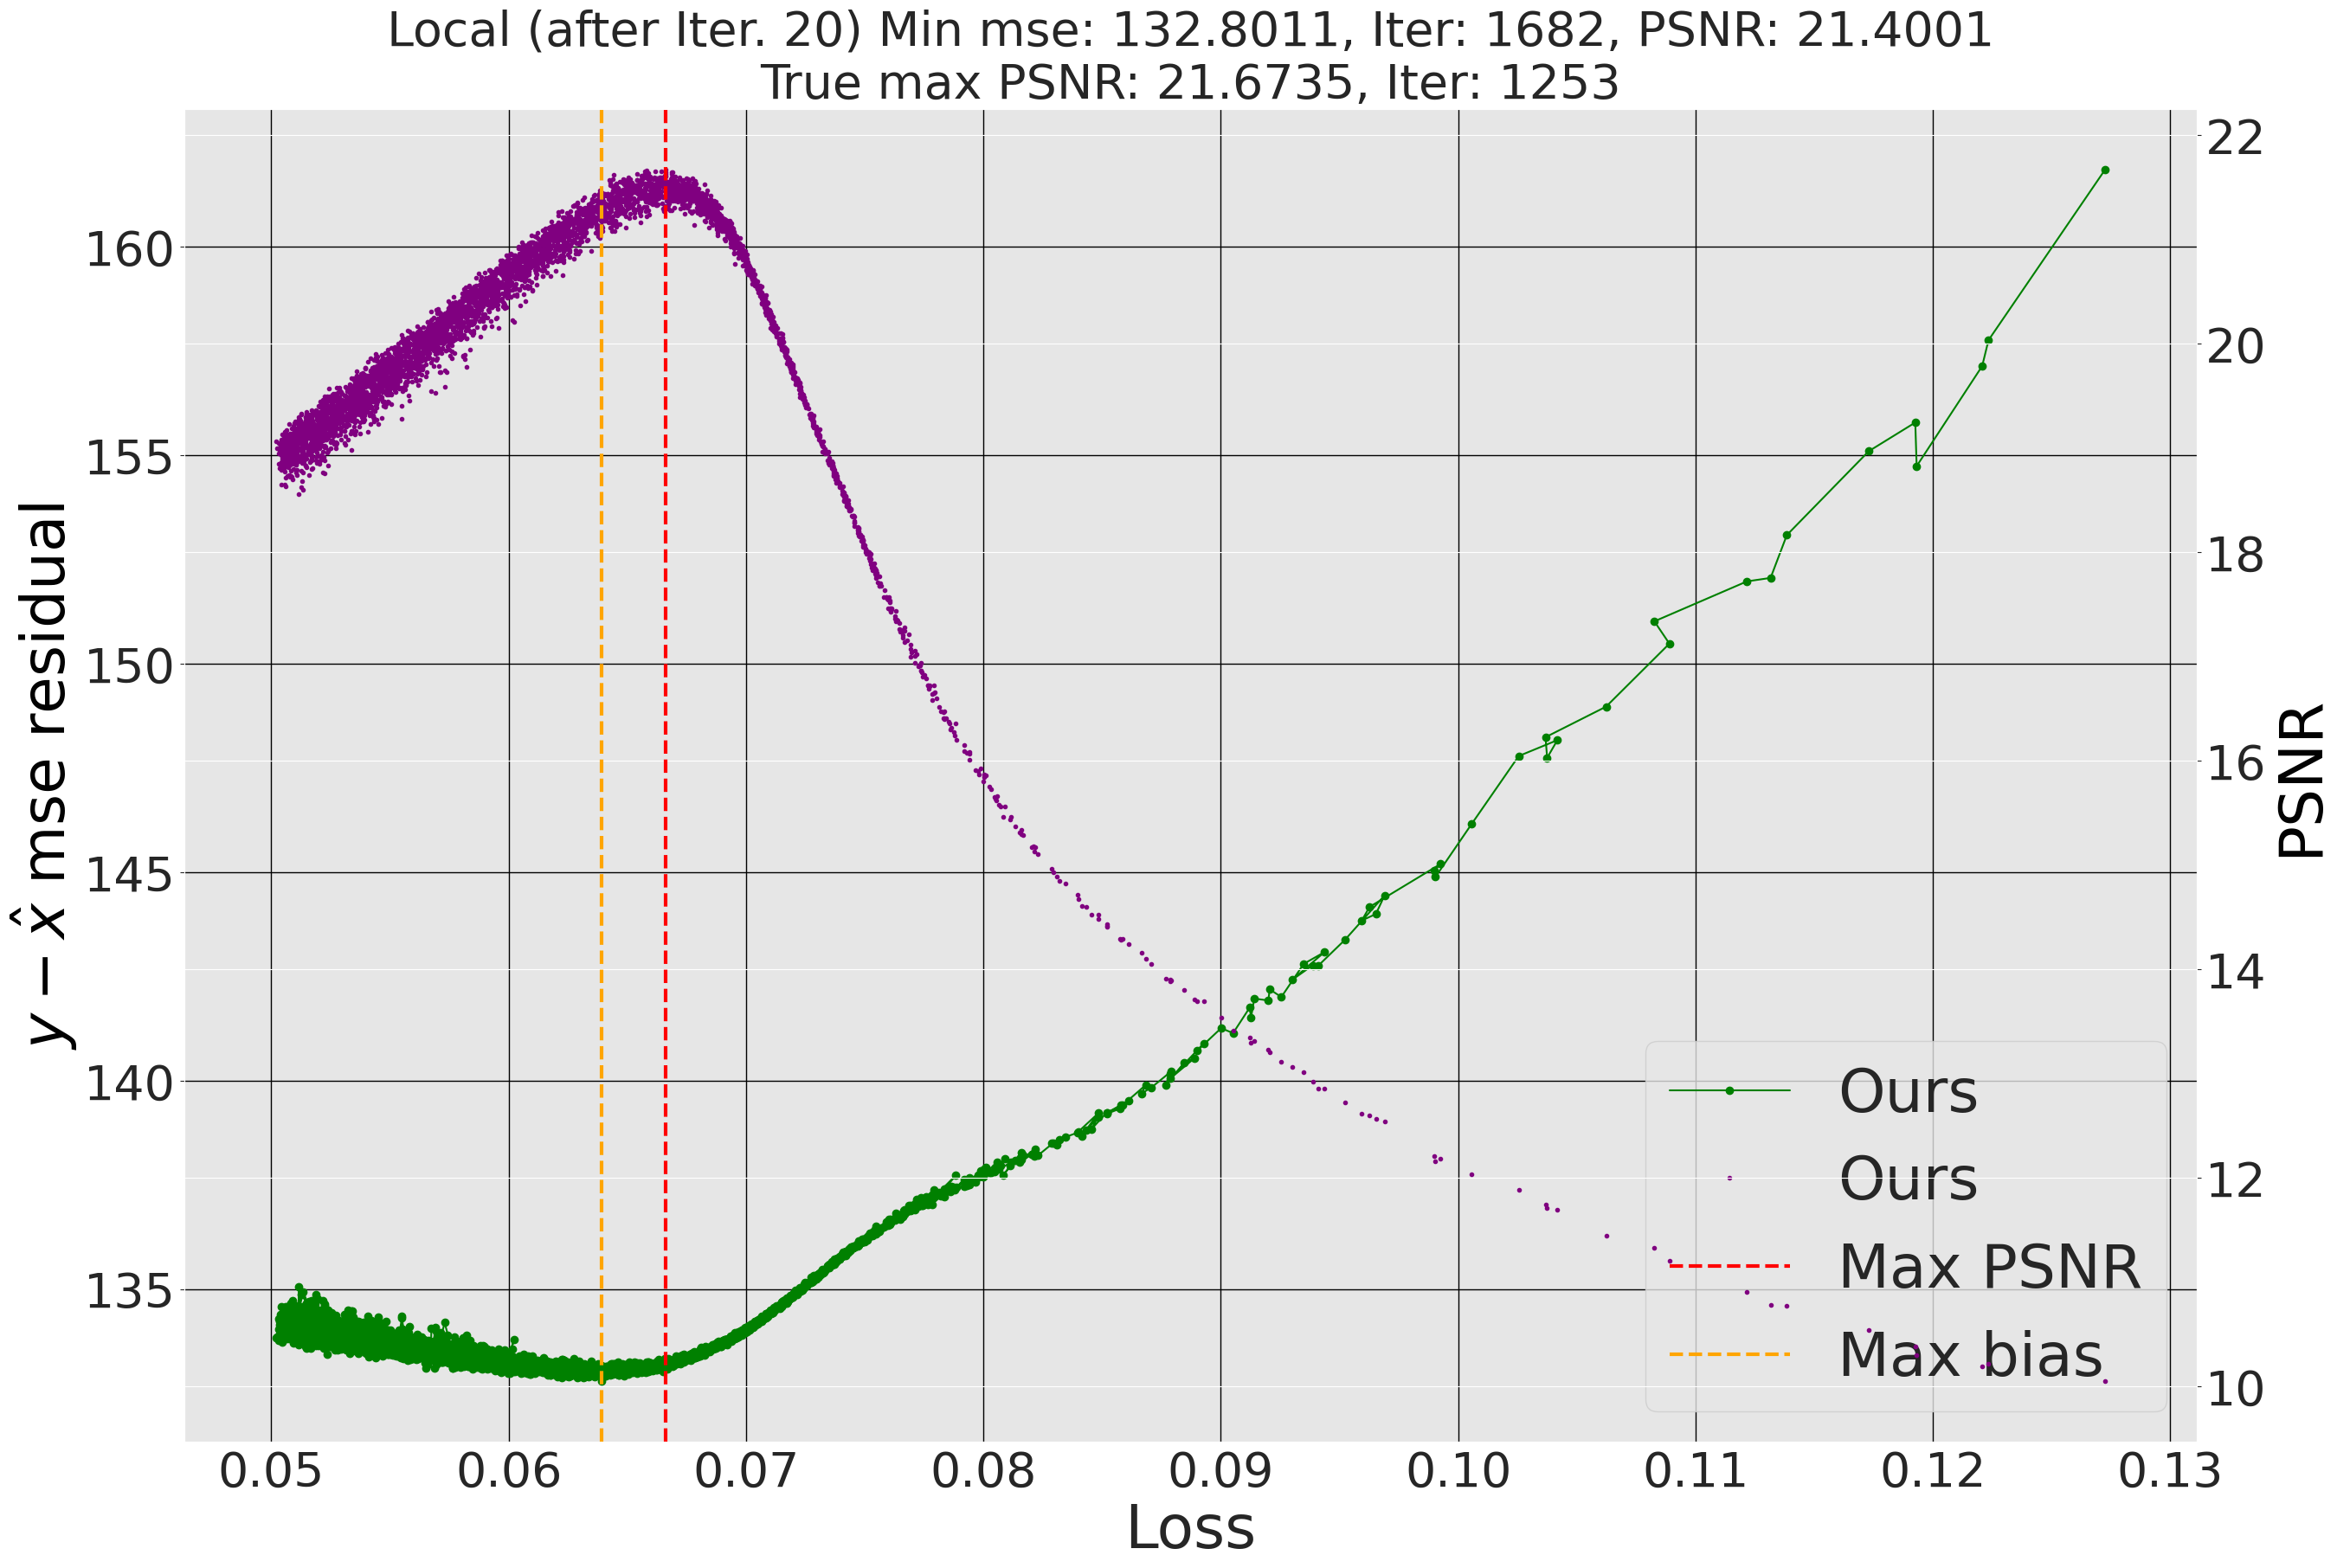

In [51]:
mse_valsy2 = []
for output in finalresult:
    mse_valsy2.append(torch.norm(np_to_torch(img_noisy_np2)[0,:,:,:]-output[0,3:6,:,:]))
vals = np.array(mse_valsy2)
maxmse_idxy2 = np.argmin(vals[20:]) + 20
# min_idx = np.argmin(vals[20:]) + 20
max_mse = vals[maxmse_idxy2]    
comse_max_psnr = psnr_history[maxmse_idxy2]
print(f'Min MSE: {max_mse:.4f}, Iter: {maxmse_idxy2}, PSNR: {comse_max_psnr:.4f}')
fig, ax1 = plt.subplots(figsize=(30,20))
ax2 = ax1.twinx()
ax1.set_xlabel("Loss", fontsize=50)
ax1.set_ylabel("$y-\hat{x}$ mse residual", color='black', fontsize=50)
ax1.plot(loss_history, mse_valsy2, marker='o', linestyle='-', label='Ours', color='green')
ax1.tick_params(axis='both', labelsize=40)   
ax2.tick_params(axis='y', labelsize=40) 
ax2.set_ylabel("PSNR", color='black', fontsize=50)
ax2.plot(loss_history, psnr_history, label=f'Ours', marker='.', linestyle=' ', color = 'purple')

# PSNR peak
ax2.axvline(x=loss_history[max_psnr_idx],color='red',linestyle='--',linewidth=3,label='Max PSNR')

# Min bias
# ax2.axvline(x=loss_history[min_idx],
#         color='blue',
#         linestyle='--',
#         linewidth=3,
#         label='Min bias')
ax2.axvline(x=loss_history[maxmse_idxy2],
        color='orange',
        linestyle='--',
        linewidth=3,
        label='Max bias')
        # Legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, fontsize=50,loc='lower right')
plt.xticks(fontsize=40)
plt.yticks(fontsize=40)
ax1.grid(True, axis='both', color='black', linestyle='-', linewidth=1, alpha=1)
plt.title(
    # f'rgb channel $y_{best_channel}-\\hat{{x}}_{best_channelx}$\n'
    # f'Local (after 300 iter.) Min bias: {min_bias:.4f}, Iter: {min_idx}, PSNR: {co_psnr:.4f}\n'
    # f'Local (after Iter. 20) Min mse: {min_bias:.4f}, Iter: {min_idx}, PSNR: {co_psnr:.4f}\n'
    # f'Local (after Iter. 20) Min bias: {min_bias:.4f}, Iter: {min_idx}, PSNR: {co_min_psnr:.4f}\n'
    f'Local (after Iter. 20) Min mse: {max_mse:.4f}, Iter: {maxmse_idxy2}, PSNR: {comse_max_psnr:.4f}\n'
    f'True max PSNR: {max_psnr:.4f}, Iter: {max_psnr_idx}',
    fontsize=40
)
# plt.savefig(f'{savename}rgb_result_mse_y_{best_channel}-x_{best_channelx}.png', dpi=300, bbox_inches='tight')
plt.show()

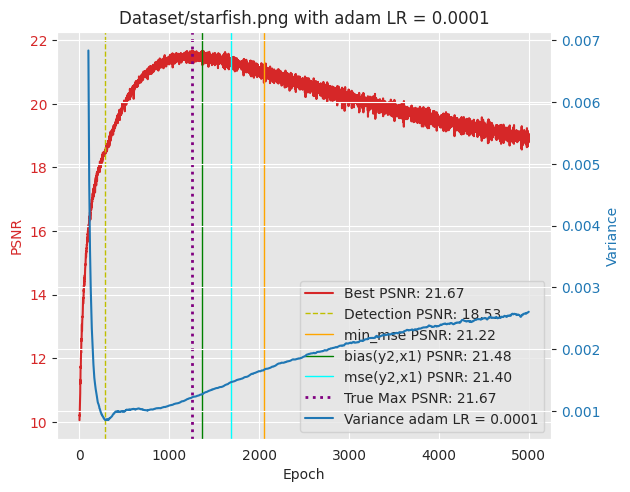

In [52]:
# show PSNR and variance history and detection
fig, ax1 = plt.subplots()

color = 'tab:red'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('PSNR', color=color)
ax1.plot(psnr_history, color=color, label=f'Best PSNR: {max_psnr:.2f}')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()

color = 'tab:blue'
ax2.set_ylabel('Variance', color=color)
ax2.plot(x_axis, variance_history, color=color, label=f'Variance {alg} LR = {lr}')
ax2.tick_params(axis='y', labelcolor=color)

# mse = [v.item() for v in best_row["mse"]]
# ax2.set_ylabel('MSE', color='green')
# ax2.plot(mse, color='green', label=f'mse')
# ax2.tick_params(axis='y', labelcolor='green')

# Early stopping detection line
ax1.axvline(
    x=earlystop.best_epoch,
    label=f'Detection PSNR: {psnr_history[earlystop.best_epoch]:.2f}',
    color='y',
    linestyle='--',
    linewidth=1
)

# Minimum PSNR gap line
ax1.axvline(
    x=best_iter,
    label=f'{best_type} PSNR: {best_psnr:.2f}',
    color='orange',
    linestyle='-',
    linewidth=1
)
ax1.axvline(
    x=max_idxy2,
    label=f'bias(y2,x1) PSNR: {co_max_psnr:.2f}',
    color='green',
    linestyle='-',
    linewidth=1
)
ax1.axvline(
    x=maxmse_idxy2,
    label=f'mse(y2,x1) PSNR: {comse_max_psnr:.2f}',
    color='cyan',
    linestyle='-',
    linewidth=1
)

# True PSNR line
ax1.axvline(
    x=max_psnr_idx,
    label=f'True Max PSNR: {max_psnr:.2f}',
    color='purple',
    linestyle='dotted',
    linewidth=2
)
fig.tight_layout()
plt.title(f'{fname} with {alg} LR = {lr}')

# 合并两个 y-axis 的 legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='best')

plt.show()

In [35]:
def find_alpha_beta_from_y_y_pairs(y, use_first3=True):
    """
    y: shape [3, H, W], [6, H, W], [1, 3, H, W], or [1, 6, H, W]

    Enumerate channel pairs:
        (0,1), (0,2), (1,0), (1,2), (2,0), (2,1)

    Equivalent to:
        alpha = e_i
        beta  = e_j
        i != j

    Solve:
        min_{i != j} || y_i - y_j ||^2

    Return:
        best_alpha, best_beta, best_loss, best_pair, records
    """

    if isinstance(y, np.ndarray):
        y_t = torch.from_numpy(y).float()
    else:
        y_t = y.detach().float().cpu()

    # remove batch dimension if needed
    if y_t.ndim == 4:
        y_t = y_t[0]

    if use_first3:
        y_t = y_t[0:3, :, :]

    assert y_t.shape[0] == 3

    records = []

    best_loss = float("inf")
    best_pair = None
    best_alpha = None
    best_beta = None

    for i in range(3):
        for j in range(3):

            # remove 0-0, 1-1, 2-2
            if i == j:
                continue

            loss = torch.mean((y_t[i] - y_t[j]) ** 2).item()

            alpha = np.zeros(3, dtype=np.float32)
            beta = np.zeros(3, dtype=np.float32)

            alpha[i] = 1.0
            beta[j] = 1.0

            records.append({
                "i": i,
                "j": j,
                "alpha": alpha,
                "beta": beta,
                "loss": loss,
                "alpha_dot_beta": float(np.dot(alpha, beta))
            })

            if loss < best_loss:
                best_loss = loss
                best_pair = (i, j)
                best_alpha = alpha
                best_beta = beta

    return best_alpha, best_beta, best_loss, best_pair, records

In [36]:
alpha, beta, loss, pair, yy_records = find_alpha_beta_from_y_y_pairs(
    y=img_noisy_np,
    use_first3=True
)

print("best pair:", pair)
print("alpha:", alpha)
print("beta:", beta)
print("alpha dot beta:", np.dot(alpha, beta))
print("loss:", loss)

best pair: (0, 1)
alpha: [1. 0. 0.]
beta: [0. 1. 0.]
alpha dot beta: 0.0
loss: 0.12158948183059692


In [37]:
fixed_residual2 = compute_fixed_alpha_beta_residual_first3(
    finalresult=finalresult,
    y_ref=img_noisy_np,
    alpha=alpha,
    beta=beta
)

In [41]:
start = 20

min_R_iter2 = np.argmin(fixed_residual2[start:]) + start
max_R_iter2 = np.argmax(fixed_residual2[start:]) + start

true_max_psnr_iter = np.argmax(psnr_history)
true_max_psnr = np.max(psnr_history)

print("Fixed alpha-beta residual min:")
print("iter:", min_R_iter2)
print("R:", fixed_residual2[min_R_iter2])
print("PSNR:", psnr_history[min_R_iter2])
print("iter gap:", abs(min_R_iter2 - true_max_psnr_iter))
print("PSNR gap:", true_max_psnr - psnr_history[min_R_iter2])

print("\nFixed alpha-beta residual max:")
print("iter:", max_R_iter2)
print("R:", fixed_residual2[max_R_iter2])
print("PSNR:", psnr_history[max_R_iter2])
print("iter gap:", abs(max_R_iter2 - true_max_psnr_iter))
print("PSNR gap:", true_max_psnr - psnr_history[max_R_iter2])

print("\nTrue max PSNR:")
print("iter:", true_max_psnr_iter)
print("PSNR:", true_max_psnr)

Fixed alpha-beta residual min:
iter: 3289
R: 0.07663384
PSNR: 19.54260867120524
iter gap: 2036
PSNR gap: 2.1308929136034642

Fixed alpha-beta residual max:
iter: 45
R: 0.093195625
PSNR: 13.890947840412585
iter gap: 1208
PSNR gap: 7.78255374439612

True max PSNR:
iter: 1253
PSNR: 21.673501584808704


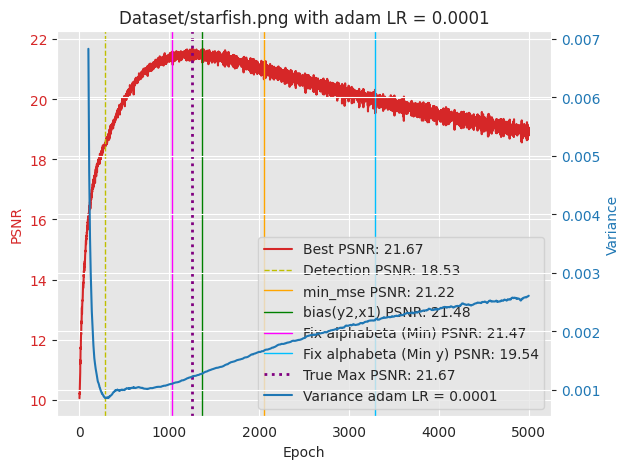

In [44]:
# show PSNR and variance history and detection
fig, ax1 = plt.subplots()

color = 'tab:red'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('PSNR', color=color)
ax1.plot(psnr_history, color=color, label=f'Best PSNR: {max_psnr:.2f}')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()

color = 'tab:blue'
ax2.set_ylabel('Variance', color=color)
ax2.plot(x_axis, variance_history, color=color, label=f'Variance {alg} LR = {lr}')
ax2.tick_params(axis='y', labelcolor=color)

# mse = [v.item() for v in best_row["mse"]]
# ax2.set_ylabel('MSE', color='green')
# ax2.plot(mse, color='green', label=f'mse')
# ax2.tick_params(axis='y', labelcolor='green')

# Early stopping detection line
ax1.axvline(
    x=earlystop.best_epoch,
    label=f'Detection PSNR: {psnr_history[earlystop.best_epoch]:.2f}',
    color='y',
    linestyle='--',
    linewidth=1
)

# Minimum PSNR gap line
ax1.axvline(
    x=best_iter,
    label=f'{best_type} PSNR: {best_psnr:.2f}',
    color='orange',
    linestyle='-',
    linewidth=1
)
ax1.axvline(
    x=max_idxy2,
    label=f'bias(y2,x1) PSNR: {co_max_psnr:.2f}',
    color='green',
    linestyle='-',
    linewidth=1
)
ax1.axvline(
    x=min_R_iter,
    label=f'Fix alphabeta (Min) PSNR: {psnr_history[min_R_iter]:.2f}',
    color='magenta',
    linestyle='-',
    linewidth=1
)

ax1.axvline(
    x=min_R_iter2,
    label=f'Fix alphabeta (Min y) PSNR: {psnr_history[min_R_iter2]:.2f}',
    color='deepskyblue',
    linestyle='-',
    linewidth=1
)
# True PSNR line
ax1.axvline(
    x=max_psnr_idx,
    label=f'True Max PSNR: {max_psnr:.2f}',
    color='purple',
    linestyle='dotted',
    linewidth=2
)
fig.tight_layout()
plt.title(f'{fname} with {alg} LR = {lr}')

fig.tight_layout()
plt.title(f'{fname} with {alg} LR = {lr}')

# 合并两个 y-axis 的 legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='best')

plt.show()

In [ ]:
import torch.nn.functional as F
def find_alpha_beta_from_two_noisy_nonnegative(
    y1, 
    y2, 
    lr=1e-2, 
    num_iter=1000, 
    n_restarts=10, 
    device=None,
    use_first3=True,):
    """
    y1, y2: shape [3,H,W], [6,H,W], [1,3,H,W], or [1,6,H,W]

    Solve:
        min_{alpha,beta} ||Y1 alpha - Y2 beta||^2

    subject to:
        ||alpha||_2 = 1,
        ||beta||_2 = 1,
        alpha^T beta = 0,
        alpha >= 0,
        beta >= 0.

    Because alpha,beta are nonnegative and orthogonal,
    their supports must be disjoint.
    """

    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    if isinstance(y1, np.ndarray):
        y1 = torch.from_numpy(y1).float()
    else:
        y1 = y1.detach().float().cpu()

    if isinstance(y2, np.ndarray):
        y2 = torch.from_numpy(y2).float()
    else:
        y2 = y2.detach().float().cpu()

    if y1.ndim == 4:
        y1 = y1[0]
    if y2.ndim == 4:
        y2 = y2[0]

    if use_first3:
        y1 = y1[0:3]
        y2 = y2[0:3]

    assert y1.shape[0] == 3
    assert y2.shape[0] == 3

    # [3,H,W] -> [N,3]
    Y1 = y1.reshape(3, -1).T.to(device)
    Y2 = y2.reshape(3, -1).T.to(device)

    N = Y1.shape[0]

    # Gram matrices
    A = (Y1.T @ Y1) / N
    B = (Y1.T @ Y2) / N
    C = (Y2.T @ Y2) / N

    C_dim = 3
    eps = 1e-12

    best_loss = float("inf")
    best_alpha = None
    best_beta = None
    best_support = None

    # enumerate all nonempty disjoint supports
    support_pairs = []

    for s_alpha in range(1, 2 ** C_dim):
        for s_beta in range(1, 2 ** C_dim):

            # disjoint support condition
            if s_alpha & s_beta:
                continue

            mask_alpha = torch.tensor(
                [(s_alpha >> k) & 1 for k in range(C_dim)],
                dtype=torch.float32,
                device=device
            )

            mask_beta = torch.tensor(
                [(s_beta >> k) & 1 for k in range(C_dim)],
                dtype=torch.float32,
                device=device
            )

            support_pairs.append((mask_alpha, mask_beta))

    for mask_alpha, mask_beta in support_pairs:
        for restart in range(n_restarts):

            u = torch.randn(C_dim, device=device, requires_grad=True)
            v = torch.randn(C_dim, device=device, requires_grad=True)

            optimizer = torch.optim.Adam([u, v], lr=lr)

            for it in range(num_iter):
                optimizer.zero_grad()

                # nonnegative weights on selected support
                alpha_raw = F.softplus(u) * mask_alpha
                beta_raw = F.softplus(v) * mask_beta

                # L2 normalization
                alpha = alpha_raw / (torch.norm(alpha_raw) + eps)
                beta = beta_raw / (torch.norm(beta_raw) + eps)

                loss = (
                    alpha @ A @ alpha
                    - 2.0 * alpha @ B @ beta
                    + beta @ C @ beta
                )

                loss.backward()
                optimizer.step()

            with torch.no_grad():
                alpha_raw = F.softplus(u) * mask_alpha
                beta_raw = F.softplus(v) * mask_beta

                alpha = alpha_raw / (torch.norm(alpha_raw) + eps)
                beta = beta_raw / (torch.norm(beta_raw) + eps)

                loss = (
                    alpha @ A @ alpha
                    - 2.0 * alpha @ B @ beta
                    + beta @ C @ beta
                ).item()

                if loss < best_loss:
                    best_loss = loss
                    best_alpha = alpha.detach().cpu().numpy()
                    best_beta = beta.detach().cpu().numpy()
                    best_support = (
                        mask_alpha.detach().cpu().numpy(),
                        mask_beta.detach().cpu().numpy()
                    )

    return best_alpha, best_beta, best_loss, best_support

The history saving thread hit an unexpected error (OperationalError('disk I/O error')).History will not be written to the database.


In [46]:
alpha3, beta3, loss3, support3 = find_alpha_beta_from_two_noisy_nonnegative(
    y1=img_noisy_np,
    y2=img_noisy_np,
    lr=1e-2,
    num_iter=1000,
    n_restarts=10,
    use_first3=True
)

print("alpha:", alpha3)
print("beta:", beta3)
print("alpha dot beta:", np.dot(alpha3, beta3))
print("loss:", loss3)
print("support alpha:", support3[0])
print("support beta:", support3[1])

alpha: [1. 0. 0.]
beta: [0.        0.5633691 0.8262053]
alpha dot beta: 0.0
loss: 0.10938966274261475
support alpha: [1. 0. 0.]
support beta: [0. 1. 1.]


In [47]:
def compute_fixed_alpha_beta_residual_first3(finalresult, y_ref, alpha, beta):
    """
    finalresult[t]: torch tensor, shape [1,6,H,W]
    y_ref: np array, shape [6,H,W] or [3,H,W]
    alpha, beta: shape [3]
    """

    if isinstance(y_ref, torch.Tensor):
        y_ref = y_ref.detach().cpu().numpy()

    if y_ref.ndim == 4:
        y_ref = y_ref[0]

    y_ref_3 = y_ref[0:3]

    gy = (
        beta[0] * y_ref_3[0]
        + beta[1] * y_ref_3[1]
        + beta[2] * y_ref_3[2]
    )

    residuals = []

    for output in finalresult:
        x_t = torch_to_np(output)[0:3]

        fx = (
            alpha[0] * x_t[0]
            + alpha[1] * x_t[1]
            + alpha[2] * x_t[2]
        )

        residual = np.mean((fx - gy) ** 2)
        residuals.append(residual)

    return np.array(residuals)

In [48]:
fixed_residual3 = compute_fixed_alpha_beta_residual_first3(
    finalresult=finalresult,
    y_ref=img_noisy_np,
    alpha=alpha3,
    beta=beta3
)

In [49]:
start = 20

min_R_iter3 = np.argmin(fixed_residual3[start:]) + start
max_R_iter3 = np.argmax(fixed_residual3[start:]) + start

true_max_psnr_iter = np.argmax(psnr_history)
true_max_psnr = np.max(psnr_history)

print("Min R iter:", min_R_iter3)
print("PSNR at Min R:", psnr_history[min_R_iter3])
print("Iter gap:", abs(min_R_iter3 - true_max_psnr_iter))
print("PSNR gap:", true_max_psnr - psnr_history[min_R_iter3])

print("Max R iter:", max_R_iter3)
print("PSNR at Max R:", psnr_history[max_R_iter3])
print("Iter gap:", abs(max_R_iter3 - true_max_psnr_iter))
print("PSNR gap:", true_max_psnr - psnr_history[max_R_iter3])

print("True max PSNR iter:", true_max_psnr_iter)
print("True max PSNR:", true_max_psnr)

Min R iter: 1931
PSNR at Min R: 20.898724206832576
Iter gap: 678
PSNR gap: 0.7747773779761289
Max R iter: 23
PSNR at Max R: 12.538137516878244
Iter gap: 1230
PSNR gap: 9.13536406793046
True max PSNR iter: 1253
True max PSNR: 21.673501584808704


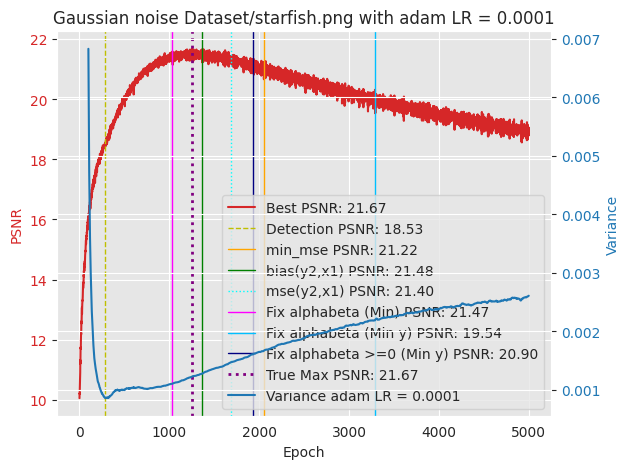

In [54]:
# show PSNR and variance history and detection
fig, ax1 = plt.subplots()

color = 'tab:red'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('PSNR', color=color)
ax1.plot(psnr_history, color=color, label=f'Best PSNR: {max_psnr:.2f}')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()

color = 'tab:blue'
ax2.set_ylabel('Variance', color=color)
ax2.plot(x_axis, variance_history, color=color, label=f'Variance {alg} LR = {lr}')
ax2.tick_params(axis='y', labelcolor=color)

# mse = [v.item() for v in best_row["mse"]]
# ax2.set_ylabel('MSE', color='green')
# ax2.plot(mse, color='green', label=f'mse')
# ax2.tick_params(axis='y', labelcolor='green')

# Early stopping detection line
ax1.axvline(
    x=earlystop.best_epoch,
    label=f'Detection PSNR: {psnr_history[earlystop.best_epoch]:.2f}',
    color='y',
    linestyle='--',
    linewidth=1
)

# Minimum PSNR gap line
ax1.axvline(
    x=best_iter,
    label=f'{best_type} PSNR: {best_psnr:.2f}',
    color='orange',
    linestyle='-',
    linewidth=1
)
ax1.axvline(
    x=max_idxy2,
    label=f'bias(y2,x1) PSNR: {co_max_psnr:.2f}',
    color='green',
    linestyle='-',
    linewidth=1
)
ax1.axvline(
    x=maxmse_idxy2,
    label=f'mse(y2,x1) PSNR: {comse_max_psnr:.2f}',
    color='cyan',
    linestyle='dotted',
    linewidth=1
)
ax1.axvline(
    x=min_R_iter,
    label=f'Fix alphabeta (Min) PSNR: {psnr_history[min_R_iter]:.2f}',
    color='magenta',
    linestyle='-',
    linewidth=1
)

ax1.axvline(
    x=min_R_iter2,
    label=f'Fix alphabeta (Min y) PSNR: {psnr_history[min_R_iter2]:.2f}',
    color='deepskyblue',
    linestyle='-',
    linewidth=1
)
ax1.axvline(
    x=min_R_iter3,
    label=f'Fix alphabeta >=0 (Min y) PSNR: {psnr_history[min_R_iter3]:.2f}',
    color='navy',
    linestyle='-',
    linewidth=1
)
# True PSNR line
ax1.axvline(
    x=max_psnr_idx,
    label=f'True Max PSNR: {max_psnr:.2f}',
    color='purple',
    linestyle='dotted',
    linewidth=2
)
fig.tight_layout()
plt.title(f'{fname} with {alg} LR = {lr}')

fig.tight_layout()
plt.title(f'Gaussian noise {fname} with {alg} LR = {lr}')

# 合并两个 y-axis 的 legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='best')

plt.show()